In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import os
import json
import pickle

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths — update if your CSVs are somewhere else ────────────
EVENTS_PATH   = "../Data/outputs/doctor_events.csv"
PROFILES_PATH = "../Data/outputs/doctor_profiles.csv"
MODEL_SAVE_PATH = "../model/temporalrx_model.pt"
SCALER_SAVE_PATH = "../model/temporalrx_scaler.pkl"

# ── Model Hyperparameters ─────────────────────────────────────
MODEL_CONFIG = {
    # Input
    "n_event_types":        33,     # number of unique event types (set properly in Chunk 2)
    "n_event_categories":   5,      # A/B/C/D/E
    "n_job_titles":         5,
    "n_specialties":        10,
    "n_practice_types":     4,
    "n_archetypes":         5,

    # Embedding dims
    "event_type_emb_dim":   16,     # event type gets a learned embedding
    "event_cat_emb_dim":    8,
    "job_title_emb_dim":    8,
    "specialty_emb_dim":    8,
    "archetype_emb_dim":    8,

    # Continuous feature count (computed in Chunk 2, set here for reference)
    # temporal + onboarding_state + memory_variables + fatigue = ~18 continuous features
    "n_continuous_features": 18,

    # LSTM
    "lstm_hidden_size":     32,
    "lstm_num_layers":      1,
    "lstm_dropout":         0.2,

    # Hawkes
    "hawkes_hidden_dim":    16,     # intermediate layer before intensity output

    # Training
    "batch_size":           64,
    "learning_rate":        1e-3,
    "n_epochs":             10,
    "max_seq_len":          100,    # truncate very long sequences
    "min_seq_len":          5,      # ignore doctors with fewer than 5 events

    # Loss weighting
    "nll_weight":           1.0,    # Hawkes negative log-likelihood loss
    "bce_weight":           0.5,    # conversion prediction loss
}

# ── Event Type Registry (must match your data generator) ──────
EVENT_TYPES_ALL = [
    # A_positive
    "app_opened", "transcription_started", "transcription_completed",
    "ai_note_reviewed", "ai_note_accepted", "ai_note_edited",
    "template_used", "feature_discovered", "settings_configured",
    "recording_started", "recording_completed",
    # B_friction
    "transcription_error", "recording_failed", "app_crashed",
    "long_load_experienced", "feature_abandoned", "help_page_opened",
    "support_chat_opened", "billing_page_visited",
    # C_social
    "colleague_invited", "referral_link_shared",
    "team_workspace_created", "colleague_accepted_invite",
    # D_lifecycle
    "email_sent", "email_opened", "email_clicked", "email_ignored",
    "in_app_nudge_shown", "in_app_nudge_clicked", "in_app_nudge_dismissed",
    # E_milestone
    "first_transcription_completed", "value_moment_reached",
    "habit_formed", "churned", "reactivated",
]

EVENT_CATEGORIES_ALL = ["A_positive", "B_friction", "C_social", "D_lifecycle", "E_milestone"]
ARCHETYPES_ALL       = ["early_adopter", "skeptical_senior", "busy_registrar", "passive_tryer", "champion"]
JOB_TITLES_ALL       = ["GP", "Specialist", "Registrar", "Nurse Practitioner", "Physician Associate"]
SPECIALTIES_ALL      = ["General Practice", "Cardiology", "Paediatrics", "Emergency", "Psychiatry",
                         "Oncology", "Neurology", "Orthopaedics", "Dermatology", "Radiology"]
PRACTICE_TYPES_ALL   = ["Solo", "Small Clinic", "Large Hospital", "Telehealth"]

# Build lookup dicts
EVENT_TYPE_TO_IDX   = {e: i for i, e in enumerate(EVENT_TYPES_ALL)}
EVENT_CAT_TO_IDX    = {c: i for i, c in enumerate(EVENT_CATEGORIES_ALL)}
ARCHETYPE_TO_IDX    = {a: i for i, a in enumerate(ARCHETYPES_ALL)}
JOB_TITLE_TO_IDX    = {j: i for i, j in enumerate(JOB_TITLES_ALL)}
SPECIALTY_TO_IDX    = {s: i for i, s in enumerate(SPECIALTIES_ALL)}
PRACTICE_TYPE_TO_IDX = {p: i for i, p in enumerate(PRACTICE_TYPES_ALL)}

print(f"  Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"  Event types registered: {len(EVENT_TYPES_ALL)}")

  Device: cpu
  Event types registered: 35


In [38]:
# ─────────────────────────────────────────────────────────────
# CHUNK 2 — Data Loading and Preprocessing
# ─────────────────────────────────────────────────────────────

# ── Load ──────────────────────────────────────────────────────
events_df   = pd.read_csv(EVENTS_PATH)
profiles_df = pd.read_csv(PROFILES_PATH)

events_df["timestamp"] = pd.to_datetime(events_df["timestamp"], format="ISO8601")
events_df = events_df.sort_values(["doc_id", "timestamp"]).reset_index(drop=True)

print(f"Events loaded:   {len(events_df):,} rows")
print(f"Doctors loaded:  {len(profiles_df):,} rows")

# ── Merge profile columns onto every event row ────────────────
profile_cols = ["doc_id", "archetype", "job_title", "specialty",
                "practice_type", "base_engagement", "skepticism",
                "error_tolerance", "fatigue_sensitivity",
                "invite_colleague_prob", "churn_risk"]

events_df = events_df.merge(profiles_df[profile_cols], on="doc_id", how="left")

# ── Handle unknowns ───────────────────────────────────────────
events_df["event_type"]     = events_df["event_type"].apply(lambda x: x if x in EVENT_TYPE_TO_IDX else "app_opened")
events_df["event_category"] = events_df["event_category"].apply(lambda x: x if x in EVENT_CAT_TO_IDX else "A_positive")
events_df["archetype"]      = events_df["archetype"].apply(lambda x: x if x in ARCHETYPE_TO_IDX else "busy_registrar")
events_df["job_title"]      = events_df["job_title"].apply(lambda x: x if x in JOB_TITLE_TO_IDX else "GP")
events_df["specialty"]      = events_df["specialty"].apply(lambda x: x if x in SPECIALTY_TO_IDX else "General Practice")
events_df["practice_type"]  = events_df["practice_type"].apply(lambda x: x if x in PRACTICE_TYPE_TO_IDX else "Solo")

# ── Fill NaNs ──────────────────────────────────────────────────
events_df = events_df.fillna(0)

# ── Define feature groups ─────────────────────────────────────
CATEGORICAL_FEATURES = {
    "event_type":     EVENT_TYPE_TO_IDX,
    "event_category": EVENT_CAT_TO_IDX,
    "archetype":      ARCHETYPE_TO_IDX,
    "job_title":      JOB_TITLE_TO_IDX,
    "specialty":      SPECIALTY_TO_IDX,
    "practice_type":  PRACTICE_TYPE_TO_IDX,
}

CONTINUOUS_FEATURES = [
    "time_since_last_event_hours",
    "time_since_signup_days",
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "is_clinic_hours",
    "event_valence",
    "onboarding_stage",
    "transcriptions_completed",
    "features_discovered",
    "trust_score",
    "sessions_total",
    "active_days",
    "cumulative_errors",
    "error_in_first_session",
    "consecutive_errors",
    "days_since_last_activity",
    "emails_ignored_streak",
    "emails_ignored_total",
    "nudges_dismissed_streak",
    "engagement_energy",
    "base_engagement",
    "skepticism",
    "error_tolerance",
    "fatigue_sensitivity",
]

MODEL_CONFIG["n_continuous_features"] = len(CONTINUOUS_FEATURES)
MODEL_CONFIG["n_event_types"]         = len(EVENT_TYPES_ALL)

# ── Encode categoricals ───────────────────────────────────────
for col, mapping in CATEGORICAL_FEATURES.items():
    events_df[col + "_idx"] = events_df[col].map(mapping).fillna(0).astype(int)

# ── STEP 1: Save raw versions BEFORE scaling ──────────────────
# Critical: label_email_category needs unscaled values.
# Must happen before StandardScaler runs.
events_df["days_since_last_activity_raw"] = events_df["days_since_last_activity"].copy()
events_df["onboarding_stage_raw"]         = events_df["onboarding_stage"].copy()
events_df["trust_score_raw"]              = events_df["trust_score"].copy()

print(f"\nRaw value ranges (pre-scaling):")
print(f"  days_since_last_activity: {events_df['days_since_last_activity_raw'].min():.1f} - {events_df['days_since_last_activity_raw'].max():.1f}")
print(f"  onboarding_stage:         {events_df['onboarding_stage_raw'].min():.0f} - {events_df['onboarding_stage_raw'].max():.0f}")
print(f"  trust_score:              {events_df['trust_score_raw'].min():.2f} - {events_df['trust_score_raw'].max():.2f}")

# ── STEP 2: Normalise continuous features ─────────────────────
scaler = StandardScaler()
events_df[CONTINUOUS_FEATURES] = scaler.fit_transform(events_df[CONTINUOUS_FEATURES])

with open(SCALER_SAVE_PATH, "wb") as f:
    pickle.dump(scaler, f)

# ── STEP 3: Compute email category label from RAW values ──────
def label_email_category(row):
    """
    Ground truth: what should be sent given this doctor's current state?
    Uses raw (unscaled) values — thresholds are meaningful here.
    """
    if row["days_since_last_activity_raw"] > 7:
        return 3   # recovery — been away too long
    stage = int(row["onboarding_stage_raw"])
    if stage <= 1:
        return 0   # activation — hasn't hit value moment yet
    if stage == 2:
        return 2 if row["trust_score_raw"] > 0.6 else 1   # social or expansion
    return 4       # commitment — habit formed, push for upgrade

events_df["email_category_label"] = events_df.apply(label_email_category, axis=1)

print(f"\nEmail category label distribution (should NOT be all zeros):")
print(events_df["email_category_label"].value_counts().sort_index())
print(f"\nCategory meanings: 0=activation 1=expansion 2=social 3=recovery 4=commitment")

# ── STEP 4: Outcome labels ────────────────────────────────────
conversion_labels = (
    events_df.groupby("doc_id")["converted"]
    .last().reset_index()
    .rename(columns={"converted": "label_converted"})
)
churn_labels = (
    events_df.groupby("doc_id")["churned"]
    .last().reset_index()
    .rename(columns={"churned": "label_churned"})
)

events_df = events_df.merge(conversion_labels, on="doc_id", how="left")
events_df = events_df.merge(churn_labels,      on="doc_id", how="left")

# ── STEP 5: Filter short sequences ────────────────────────────
event_counts = events_df.groupby("doc_id").size()
valid_docs   = event_counts[event_counts >= MODEL_CONFIG["min_seq_len"]].index
events_df    = events_df[events_df["doc_id"].isin(valid_docs)].reset_index(drop=True)

print(f"\nAfter filtering:")
print(f"  Valid doctors:       {events_df['doc_id'].nunique():,}")
print(f"  Total events:        {len(events_df):,}")
print(f"  Continuous features: {len(CONTINUOUS_FEATURES)}")
print(f"  Conversion rate:     {events_df.groupby('doc_id')['label_converted'].last().mean():.1%}")
print(f"  Churn rate:          {events_df.groupby('doc_id')['label_churned'].last().mean():.1%}")

# ── STEP 6: Train / Val / Test split by doctor ────────────────
all_doc_ids = events_df["doc_id"].unique()
train_docs, temp_docs = train_test_split(all_doc_ids, test_size=0.30, random_state=SEED)
val_docs,   test_docs = train_test_split(temp_docs,   test_size=0.50, random_state=SEED)

train_df = events_df[events_df["doc_id"].isin(train_docs)].copy()
val_df   = events_df[events_df["doc_id"].isin(val_docs)].copy()
test_df  = events_df[events_df["doc_id"].isin(test_docs)].copy()

print(f"\nSplit:")
print(f"  Train doctors: {len(train_docs):,}")
print(f"  Val doctors:   {len(val_docs):,}")
print(f"  Test doctors:  {len(test_docs):,}")
print(f"\n✓ Chunk 2 complete")

Events loaded:   1,332,818 rows
Doctors loaded:  10,000 rows

Raw value ranges (pre-scaling):
  days_since_last_activity: -1.1 - 15.0
  onboarding_stage:         0 - 3
  trust_score:              0.00 - 1.00

Email category label distribution (should NOT be all zeros):
email_category_label
0    146226
1    176753
2    123441
3     33085
4    853313
Name: count, dtype: int64

Category meanings: 0=activation 1=expansion 2=social 3=recovery 4=commitment

After filtering:
  Valid doctors:       10,000
  Total events:        1,332,818
  Continuous features: 25
  Conversion rate:     5.7%
  Churn rate:          70.8%

Split:
  Train doctors: 7,000
  Val doctors:   1,500
  Test doctors:  1,500

✓ Chunk 2 complete


In [39]:
# ─────────────────────────────────────────────────────────────
# CHUNK 3 — Sequence Builder + PyTorch Dataset
# ─────────────────────────────────────────────────────────────
# Turns the flat event DataFrame into sequences per doctor.
# Each doctor becomes one training sample:
#   - a sequence of event vectors (variable length)
#   - a label (converted or not)
#   - inter-event time deltas (for Hawkes loss)
# ─────────────────────────────────────────────────────────────

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Categorical index column names ────────────────────────────
CAT_IDX_COLS = [col + "_idx" for col in CATEGORICAL_FEATURES.keys()]
# = ["event_type_idx", "event_category_idx", "archetype_idx",
#    "job_title_idx", "specialty_idx", "practice_type_idx"]


def build_sequences_from_df(df: pd.DataFrame, max_len: int) -> list:
    """
    Convert a flat events DataFrame into a list of per-doctor sequence dicts.

    Each dict contains:
        cat_seq:    (seq_len, n_categoricals) int tensor — categorical feature indices
        cont_seq:   (seq_len, n_continuous)   float tensor — normalised continuous features
        delta_seq:  (seq_len,)                float tensor — inter-event times in hours
        label:      scalar float — 1.0 if doctor converted, 0.0 if not
        seq_len:    int — actual length before padding
        doc_id:     str — for reference
    """
    sequences = []

    for doc_id, group in df.groupby("doc_id"):
        group = group.sort_values("timestamp").reset_index(drop=True)

        # Truncate very long sequences from the front
        # (keep the most recent events — more predictive)
        if len(group) > max_len:
            group = group.iloc[-max_len:]

        seq_len = len(group)

        # ── Categorical indices ────────────────────────────────
        cat_seq = torch.tensor(
            group[CAT_IDX_COLS].values,
            dtype=torch.long
        )   # shape: (seq_len, 6)

        # ── Continuous features ────────────────────────────────
        cont_seq = torch.tensor(
            group[CONTINUOUS_FEATURES].values,
            dtype=torch.float32
        )   # shape: (seq_len, 25)

        # ── Inter-event delta times ────────────────────────────
        # This is the raw dt used in the Hawkes intensity function.
        # We use the UNNORMALISED time_since_last_event_hours here
        # because Hawkes needs actual time gaps, not scaled ones.
        # We recompute from timestamps directly to be safe.
        timestamps = group["timestamp"].values
        deltas = np.zeros(seq_len, dtype=np.float32)
        for i in range(1, seq_len):
            dt_hours = (pd.Timestamp(timestamps[i]) - pd.Timestamp(timestamps[i-1])).total_seconds() / 3600
            deltas[i] = max(0.0, dt_hours)

        delta_seq = torch.tensor(deltas, dtype=torch.float32)   # shape: (seq_len,)

        # ── Label ──────────────────────────────────────────────
        label = float(group["label_converted"].iloc[-1])

        sequences.append({
            "doc_id":   doc_id,
            "cat_seq":  cat_seq,
            "cont_seq": cont_seq,
            "delta_seq": delta_seq,
            "label":    label,
            "seq_len":  seq_len,
        })

    return sequences


# ── Build sequences from each split ───────────────────────────
print("Building sequences...")
train_sequences = build_sequences_from_df(train_df, MODEL_CONFIG["max_seq_len"])
val_sequences   = build_sequences_from_df(val_df,   MODEL_CONFIG["max_seq_len"])
test_sequences  = build_sequences_from_df(test_df,  MODEL_CONFIG["max_seq_len"])

print(f"  Train sequences: {len(train_sequences):,}")
print(f"  Val sequences:   {len(val_sequences):,}")
print(f"  Test sequences:  {len(test_sequences):,}")

# ── PyTorch Dataset ────────────────────────────────────────────

class DoctorSequenceDataset(Dataset):
    """
    Wraps a list of sequence dicts into a PyTorch Dataset.
    The __getitem__ returns one doctor's data.
    The collate_fn below handles variable-length padding into batches.
    """
    def __init__(self, sequences: list):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def collate_fn(batch: list) -> dict:
    """
    Collates a list of variable-length sequence dicts into padded batch tensors.

    Why padding: LSTM requires fixed-size tensors in a batch.
    Shorter sequences are padded with zeros at the END.
    We also return seq_lengths so pack_padded_sequence can ignore padding.
    """
    batch = sorted(batch, key=lambda x: x["seq_len"], reverse=True)   # longest first

    seq_lengths = torch.tensor([s["seq_len"] for s in batch], dtype=torch.long)
    labels      = torch.tensor([s["label"]   for s in batch], dtype=torch.float32)

    # Pad categorical sequences
    cat_padded = pad_sequence(
        [s["cat_seq"] for s in batch],
        batch_first=True,
        padding_value=0
    )   # shape: (batch, max_seq_len, 6)

    # Pad continuous sequences
    cont_padded = pad_sequence(
        [s["cont_seq"] for s in batch],
        batch_first=True,
        padding_value=0.0
    )   # shape: (batch, max_seq_len, 25)

    # Pad delta sequences
    delta_padded = pad_sequence(
        [s["delta_seq"] for s in batch],
        batch_first=True,
        padding_value=0.0
    )   # shape: (batch, max_seq_len)

    doc_ids = [s["doc_id"] for s in batch]

    return {
        "cat_seq":    cat_padded,
        "cont_seq":   cont_padded,
        "delta_seq":  delta_padded,
        "seq_lengths": seq_lengths,
        "labels":     labels,
        "doc_ids":    doc_ids,
    }


# ── DataLoaders ────────────────────────────────────────────────
train_loader = DataLoader(
    DoctorSequenceDataset(train_sequences),
    batch_size=MODEL_CONFIG["batch_size"],
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    DoctorSequenceDataset(val_sequences),
    batch_size=MODEL_CONFIG["batch_size"],
    shuffle=False,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    DoctorSequenceDataset(test_sequences),
    batch_size=MODEL_CONFIG["batch_size"],
    shuffle=False,
    collate_fn=collate_fn,
)

print(f"\nDataLoaders ready:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

# ── Quick shape check ──────────────────────────────────────────
sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  cat_seq:    {sample_batch['cat_seq'].shape}    (batch, seq_len, 6 categoricals)")
print(f"  cont_seq:   {sample_batch['cont_seq'].shape}   (batch, seq_len, {len(CONTINUOUS_FEATURES)} continuous)")
print(f"  delta_seq:  {sample_batch['delta_seq'].shape}  (batch, seq_len)")
print(f"  labels:     {sample_batch['labels'].shape}")
print(f"\n✓ Chunk 3 complete — sequences built, DataLoaders ready")

Building sequences...
  Train sequences: 7,000
  Val sequences:   1,500
  Test sequences:  1,500

DataLoaders ready:
  Train batches: 110
  Val batches:   24
  Test batches:  24

Sample batch shapes:
  cat_seq:    torch.Size([64, 100, 6])    (batch, seq_len, 6 categoricals)
  cont_seq:   torch.Size([64, 100, 25])   (batch, seq_len, 25 continuous)
  delta_seq:  torch.Size([64, 100])  (batch, seq_len)
  labels:     torch.Size([64])

✓ Chunk 3 complete — sequences built, DataLoaders ready


In [40]:
# ─────────────────────────────────────────────────────────────
# CHUNK 4 (UPDATED) — Model Architecture
# ─────────────────────────────────────────────────────────────
# Three output heads:
#   1. NeuralHawkesHead  → λ(t) intensity curve
#   2. ConversionHead    → will this doctor convert? (probability)
#   3. EmailCategoryHead → what type of email to send? (5 classes)
#
# Every event triggers a full forward pass → all three update.
# ─────────────────────────────────────────────────────────────


class InputEncoder(nn.Module):
    def __init__(self, config: dict):
        super().__init__()
        c = config
        self.event_type_emb    = nn.Embedding(c["n_event_types"],     c["event_type_emb_dim"])
        self.event_cat_emb     = nn.Embedding(c["n_event_categories"], c["event_cat_emb_dim"])
        self.archetype_emb     = nn.Embedding(c["n_archetypes"],       c["archetype_emb_dim"])
        self.job_title_emb     = nn.Embedding(c["n_job_titles"],       c["job_title_emb_dim"])
        self.specialty_emb     = nn.Embedding(c["n_specialties"],      c["specialty_emb_dim"])
        self.practice_type_emb = nn.Embedding(c["n_practice_types"],   8)

        self.total_emb_dim = (
            c["event_type_emb_dim"] + c["event_cat_emb_dim"] +
            c["archetype_emb_dim"]  + c["job_title_emb_dim"] +
            c["specialty_emb_dim"]  + 8
        )
        self.cont_proj   = nn.Linear(c["n_continuous_features"], 56)
        self.output_proj = nn.Sequential(
            nn.Linear(self.total_emb_dim + 56, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
        )
        self.output_dim = 128

    def forward(self, cat_seq, cont_seq):
        e = torch.cat([
            self.event_type_emb(cat_seq[:, :, 0]),
            self.event_cat_emb(cat_seq[:, :, 1]),
            self.archetype_emb(cat_seq[:, :, 2]),
            self.job_title_emb(cat_seq[:, :, 3]),
            self.specialty_emb(cat_seq[:, :, 4]),
            self.practice_type_emb(cat_seq[:, :, 5]),
        ], dim=-1)
        c = torch.relu(self.cont_proj(cont_seq))
        return self.output_proj(torch.cat([e, c], dim=-1))


class LSTMEncoder(nn.Module):
    def __init__(self, config: dict, input_dim: int):
        super().__init__()
        self.hidden_size = config["lstm_hidden_size"]
        self.num_layers  = config["lstm_num_layers"]
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            batch_first=True,
            dropout=config["lstm_dropout"] if self.num_layers > 1 else 0.0,
        )

    def forward(self, x, seq_lengths, hidden_state=None):
        """
        hidden_state: optional (hn, cn) for incremental inference.
        Training:     always None — process full sequence from scratch.
        Live inference: pass previous (hn, cn) — LSTM continues from last event.
        """
        packed = pack_padded_sequence(x, seq_lengths.cpu(), batch_first=True, enforce_sorted=True)
        packed_output, (hn, cn) = self.lstm(packed, hidden_state)
        all_hidden, _ = pad_packed_sequence(packed_output, batch_first=True)

        idx = (seq_lengths - 1).clamp(min=0).unsqueeze(1).unsqueeze(2)
        idx = idx.expand(-1, 1, self.hidden_size).to(all_hidden.device)
        final_hidden = all_hidden.gather(1, idx).squeeze(1)
        final_cell   = cn[-1]

        return all_hidden, final_hidden, final_cell, (hn, cn)


class NeuralHawkesHead(nn.Module):
    """
    Three heads, all conditioned on LSTM hidden + cell state.

    Head 1 — Hawkes Intensity:
        λ(t) = softplus(base(h)) · exp(-softplus(decay(h)) · Δt)
        Both base intensity AND decay rate are learned from hidden state.
        Same event produces different intensity curves for different doctors.

    Head 2 — Conversion:
        P(convert) = sigmoid(MLP([h, c]))
        h = what's happening right now (hidden state)
        c = accumulated journey memory (cell state)

    Head 3 — Email Category:
        P(category) = softmax(MLP([h, c]))
        5 classes: activation, expansion, social, recovery, commitment
        The model learns which journey context → which email type.
        Not rules. Learned from thousands of doctor trajectories.
    """
    def __init__(self, config: dict):
        super().__init__()
        hidden = config["lstm_hidden_size"]
        hd     = config["hawkes_hidden_dim"]

        self.base_intensity_net = nn.Sequential(
            nn.Linear(hidden, hd), nn.Tanh(), nn.Linear(hd, 1)
        )
        self.decay_rate_net = nn.Sequential(
            nn.Linear(hidden, hd), nn.Tanh(), nn.Linear(hd, 1)
        )
        self.conversion_head = nn.Sequential(
            nn.Linear(hidden * 2, hd), nn.ReLU(), nn.Dropout(0.3), nn.Linear(hd, 1)
        )
        self.email_category_head = nn.Sequential(
            nn.Linear(hidden * 2, hd), nn.ReLU(), nn.Dropout(0.3), nn.Linear(hd, 5)
        )

    def forward(self, all_hidden, final_hidden, final_cell, delta_seq, seq_lengths):
        # Head 1: intensity at each observed timestep
        base  = torch.nn.functional.softplus(self.base_intensity_net(all_hidden))
        decay = torch.nn.functional.softplus(self.decay_rate_net(all_hidden)) + 0.01
        lambda_seq = (base * torch.exp(-decay * delta_seq.unsqueeze(-1))).squeeze(-1)

        # Shared context: short-term (hidden) + long-term (cell)
        context = torch.cat([final_hidden, final_cell], dim=-1)

        # Head 2: conversion probability
        conversion_logit = self.conversion_head(context)

        # Head 3: email category
        email_logits = self.email_category_head(context)

        return lambda_seq, conversion_logit, email_logits


class TemporalRxModel(nn.Module):
    """
    Full TemporalRx model.

    Training:   full sequence in → three outputs → three losses
    Inference:  one new event in → hidden state updates → all three outputs refresh

    The hidden_state passthrough is what enables live incremental prediction.
    You don't reprocess the full history on every event — you just continue
    the LSTM from its last state. O(1) per new event, not O(sequence_length).
    """
    def __init__(self, config: dict):
        super().__init__()
        self.input_encoder = InputEncoder(config)
        self.lstm_encoder  = LSTMEncoder(config, input_dim=self.input_encoder.output_dim)
        self.hawkes_head   = NeuralHawkesHead(config)

    def forward(self, cat_seq, cont_seq, delta_seq, seq_lengths, hidden_state=None):
        encoded = self.input_encoder(cat_seq, cont_seq)
        all_hidden, final_hidden, final_cell, new_hidden_state = self.lstm_encoder(
            encoded, seq_lengths, hidden_state
        )
        lambda_seq, conversion_logit, email_logits = self.hawkes_head(
            all_hidden, final_hidden, final_cell, delta_seq, seq_lengths
        )
        return lambda_seq, conversion_logit, email_logits, new_hidden_state


# ── Instantiate ───────────────────────────────────────────────
model = TemporalRxModel(MODEL_CONFIG).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Chunk 4 loaded")
print(f"  Parameters: {total_params:,}")
print(f"  Head 1: Hawkes intensity λ(t)")
print(f"  Head 2: Conversion probability")
print(f"  Head 3: Email category (5 classes)")
print(f"  LSTM: incremental inference via hidden_state passthrough")

✓ Chunk 4 loaded
  Parameters: 40,976
  Head 1: Hawkes intensity λ(t)
  Head 2: Conversion probability
  Head 3: Email category (5 classes)
  LSTM: incremental inference via hidden_state passthrough


Building sequences...

Email label distribution in train sequences:
{1: 90, 2: 42, 3: 5092, 4: 1776}
If all 0s here — chunk 2 raw columns still wrong. Stop and fix chunk 2 first.

Conversion class balance: pos=574 neg=9426 pos_weight=16.42

Training on cpu for up to 10 epochs...

  Ep |   TrLoss |    NLL |    BCE |     CE |   VlLoss |  ConvAcc |  EmailAcc
--------------------------------------------------------------------------------
   1 |   5.6798 |  5.028 |  0.893 |  0.685 |   3.3093 |   65.4% |    95.1% ✓
   2 |   3.3291 |  2.897 |  0.765 |  0.166 |   1.7610 |   67.0% |    96.3% ✓
   3 |   2.3899 |  1.978 |  0.747 |  0.126 |   1.5957 |   68.3% |    97.5% ✓
   4 |   2.2888 |  1.897 |  0.724 |  0.100 |   1.4421 |   72.5% |    97.6% ✓
   5 |   2.2511 |  1.861 |  0.729 |  0.085 |   1.4235 |   70.1% |    97.5% ✓
   6 |   2.2020 |  1.832 |  0.699 |  0.068 |   1.3725 |   72.1% |    98.9% ✓
   7 |   2.1841 |  1.817 |  0.698 |  0.063 |   1.3753 |   74.0% |    98.9%
   8 |   2.1682 |  1.800

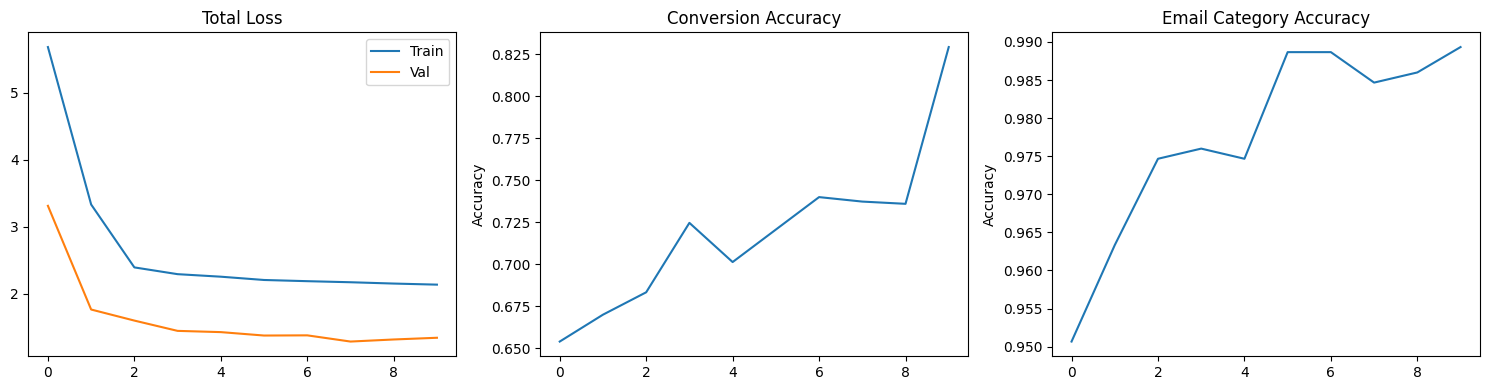


✓ Chunk 5 complete


In [41]:
# ─────────────────────────────────────────────────────────────
# CHUNK 5 (UPDATED) — Training Loop
# ─────────────────────────────────────────────────────────────

from sklearn.metrics import classification_report

# ── Rebuild sequences and dataloaders ─────────────────────────
# Re-split from events_df to pick up email_category_label
train_df = events_df[events_df["doc_id"].isin(train_docs)].copy()
val_df   = events_df[events_df["doc_id"].isin(val_docs)].copy()
test_df  = events_df[events_df["doc_id"].isin(test_docs)].copy()

def build_sequences_from_df(df, max_len):
    sequences = []
    for doc_id, group in df.groupby("doc_id"):
        group = group.sort_values("timestamp").reset_index(drop=True)
        if len(group) > max_len:
            group = group.iloc[-max_len:]
        seq_len = len(group)

        cat_seq  = torch.tensor(group[CAT_IDX_COLS].values, dtype=torch.long)
        cont_seq = torch.tensor(group[CONTINUOUS_FEATURES].values, dtype=torch.float32)

        timestamps = group["timestamp"].values
        deltas = np.zeros(seq_len, dtype=np.float32)
        for i in range(1, seq_len):
            dt_h = (pd.Timestamp(timestamps[i]) - pd.Timestamp(timestamps[i-1])).total_seconds() / 3600
            deltas[i] = max(0.0, dt_h)
        delta_seq = torch.tensor(deltas, dtype=torch.float32)

        label           = float(group["label_converted"].iloc[-1])
        email_cat_label = int(group["email_category_label"].iloc[-1])

        sequences.append({
            "doc_id":          doc_id,
            "cat_seq":         cat_seq,
            "cont_seq":        cont_seq,
            "delta_seq":       delta_seq,
            "label":           label,
            "email_cat_label": email_cat_label,
            "seq_len":         seq_len,
        })
    return sequences


def collate_fn(batch):
    batch = sorted(batch, key=lambda x: x["seq_len"], reverse=True)
    seq_lengths      = torch.tensor([s["seq_len"]         for s in batch], dtype=torch.long)
    labels           = torch.tensor([s["label"]           for s in batch], dtype=torch.float32)
    email_cat_labels = torch.tensor([s["email_cat_label"] for s in batch], dtype=torch.long)
    cat_padded       = pad_sequence([s["cat_seq"]   for s in batch], batch_first=True, padding_value=0)
    cont_padded      = pad_sequence([s["cont_seq"]  for s in batch], batch_first=True, padding_value=0.0)
    delta_padded     = pad_sequence([s["delta_seq"] for s in batch], batch_first=True, padding_value=0.0)
    return {
        "cat_seq":          cat_padded,
        "cont_seq":         cont_padded,
        "delta_seq":        delta_padded,
        "seq_lengths":      seq_lengths,
        "labels":           labels,
        "email_cat_labels": email_cat_labels,
        "doc_ids":          [s["doc_id"] for s in batch],
    }


print("Building sequences...")
train_sequences = build_sequences_from_df(train_df, MODEL_CONFIG["max_seq_len"])
val_sequences   = build_sequences_from_df(val_df,   MODEL_CONFIG["max_seq_len"])
test_sequences  = build_sequences_from_df(test_df,  MODEL_CONFIG["max_seq_len"])

# Sanity check email label distribution in sequences
train_email_labels = [s["email_cat_label"] for s in train_sequences]
print(f"\nEmail label distribution in train sequences:")
import collections
print(dict(sorted(collections.Counter(train_email_labels).items())))
print("If all 0s here — chunk 2 raw columns still wrong. Stop and fix chunk 2 first.")

train_loader = DataLoader(DoctorSequenceDataset(train_sequences), batch_size=MODEL_CONFIG["batch_size"], shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(DoctorSequenceDataset(val_sequences),   batch_size=MODEL_CONFIG["batch_size"], shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(DoctorSequenceDataset(test_sequences),  batch_size=MODEL_CONFIG["batch_size"], shuffle=False, collate_fn=collate_fn)

# ── Class weights ─────────────────────────────────────────────
all_labels = events_df.groupby("doc_id")["label_converted"].last()
n_neg      = (all_labels == 0).sum()
n_pos      = (all_labels == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f"\nConversion class balance: pos={n_pos} neg={n_neg} pos_weight={pos_weight.item():.2f}")

# ── Training functions ────────────────────────────────────────

def train_one_epoch(model, loader, optimiser):
    model.train()
    total_loss = total_nll = total_bce = total_ce = 0.0
    n_batches = 0

    for batch in loader:
        cat_seq          = batch["cat_seq"].to(DEVICE)
        cont_seq         = batch["cont_seq"].to(DEVICE)
        delta_seq        = batch["delta_seq"].to(DEVICE)
        seq_lengths      = batch["seq_lengths"].to(DEVICE)
        labels           = batch["labels"].to(DEVICE)
        email_cat_labels = batch["email_cat_labels"].to(DEVICE)

        optimiser.zero_grad()

        lambda_seq, conversion_logit, email_logits, _ = model(
            cat_seq, cont_seq, delta_seq, seq_lengths
        )

        # Loss 1: Hawkes NLL
        B, T = lambda_seq.shape
        mask = torch.zeros(B, T, device=DEVICE)
        for i, l in enumerate(seq_lengths):
            mask[i, :l] = 1.0
        lam_c    = lambda_seq.clamp(min=1e-8)
        nll_loss = ((-torch.log(lam_c) * mask + lam_c * delta_seq * mask).sum(1) / seq_lengths.float()).mean()

        # Loss 2: BCE conversion (class-weighted)
        bce_loss = nn.functional.binary_cross_entropy_with_logits(
            conversion_logit.squeeze(-1), labels, pos_weight=pos_weight
        )

        # Loss 3: CrossEntropy email category
        ce_loss = nn.functional.cross_entropy(email_logits, email_cat_labels)

        loss = MODEL_CONFIG["nll_weight"] * nll_loss + MODEL_CONFIG["bce_weight"] * bce_loss + 0.3 * ce_loss

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()

        total_loss += loss.item()
        total_nll  += nll_loss.item()
        total_bce  += bce_loss.item()
        total_ce   += ce_loss.item()
        n_batches  += 1

    return total_loss/n_batches, total_nll/n_batches, total_bce/n_batches, total_ce/n_batches


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = total_nll = total_bce = total_ce = 0.0
    all_conv_preds = []; all_conv_labels = []
    all_email_preds = []; all_email_labels = []
    n_batches = 0

    for batch in loader:
        cat_seq          = batch["cat_seq"].to(DEVICE)
        cont_seq         = batch["cont_seq"].to(DEVICE)
        delta_seq        = batch["delta_seq"].to(DEVICE)
        seq_lengths      = batch["seq_lengths"].to(DEVICE)
        labels           = batch["labels"].to(DEVICE)
        email_cat_labels = batch["email_cat_labels"].to(DEVICE)

        lambda_seq, conversion_logit, email_logits, _ = model(
            cat_seq, cont_seq, delta_seq, seq_lengths
        )

        B, T = lambda_seq.shape
        mask = torch.zeros(B, T, device=DEVICE)
        for i, l in enumerate(seq_lengths):
            mask[i, :l] = 1.0
        lam_c    = lambda_seq.clamp(min=1e-8)
        nll_loss = ((-torch.log(lam_c) * mask).sum(1) / seq_lengths.float()).mean()
        bce_loss = nn.functional.binary_cross_entropy_with_logits(
            conversion_logit.squeeze(-1), labels, pos_weight=pos_weight
        )
        ce_loss  = nn.functional.cross_entropy(email_logits, email_cat_labels)
        loss     = MODEL_CONFIG["nll_weight"] * nll_loss + MODEL_CONFIG["bce_weight"] * bce_loss + 0.3 * ce_loss

        total_loss += loss.item(); total_nll += nll_loss.item()
        total_bce  += bce_loss.item(); total_ce += ce_loss.item()
        n_batches  += 1

        all_conv_preds.extend(torch.sigmoid(conversion_logit.squeeze(-1)).cpu().tolist())
        all_conv_labels.extend(labels.cpu().tolist())
        all_email_preds.extend(email_logits.argmax(-1).cpu().tolist())
        all_email_labels.extend(email_cat_labels.cpu().tolist())

    n         = len(all_conv_labels)
    conv_acc  = sum(int(p > 0.5) == int(l) for p, l in zip(all_conv_preds,  all_conv_labels))  / n
    email_acc = sum(p == l                  for p, l in zip(all_email_preds, all_email_labels)) / n

    return (total_loss/n_batches, total_nll/n_batches, total_bce/n_batches, total_ce/n_batches,
            conv_acc, email_acc, all_conv_preds, all_conv_labels, all_email_preds, all_email_labels)


# ── Training run ──────────────────────────────────────────────
optimiser = optim.Adam(model.parameters(), lr=MODEL_CONFIG["learning_rate"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimiser, patience=3, factor=0.5)

history = {"train_loss": [], "val_loss": [], "val_conv_acc": [], "val_email_acc": []}
best_val_loss    = float("inf")
patience_counter = 0
EARLY_STOP       = 5

print(f"\nTraining on {DEVICE} for up to {MODEL_CONFIG['n_epochs']} epochs...\n")
print(f"{'Ep':>4} | {'TrLoss':>8} | {'NLL':>6} | {'BCE':>6} | {'CE':>6} | {'VlLoss':>8} | {'ConvAcc':>8} | {'EmailAcc':>9}")
print("-" * 80)

for epoch in range(1, MODEL_CONFIG["n_epochs"] + 1):
    tr_loss, tr_nll, tr_bce, tr_ce = train_one_epoch(model, train_loader, optimiser)
    vl_loss, vl_nll, vl_bce, vl_ce, conv_acc, email_acc, _, _, _, _ = evaluate(model, val_loader)

    scheduler.step(vl_loss)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["val_conv_acc"].append(conv_acc)
    history["val_email_acc"].append(email_acc)

    saved = ""
    if vl_loss < best_val_loss:
        best_val_loss    = vl_loss
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        saved = " ✓"
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP:
            print(f"Early stopping at epoch {epoch}")
            break

    print(f"{epoch:>4} | {tr_loss:>8.4f} | {tr_nll:>6.3f} | {tr_bce:>6.3f} | {tr_ce:>6.3f} | "
          f"{vl_loss:>8.4f} | {conv_acc:>7.1%} | {email_acc:>8.1%}{saved}")

# ── Load best model ───────────────────────────────────────────
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))

# ── Full test evaluation with classification reports ──────────
te_loss, te_nll, te_bce, te_ce, te_conv, te_email, \
    conv_preds, conv_labels, email_preds, email_labels = evaluate(model, test_loader)

print(f"\n{'='*60}")
print(f"TEST RESULTS")
print(f"{'='*60}")
print(f"  Total Loss:        {te_loss:.4f}")
print(f"  Hawkes NLL:        {te_nll:.4f}")
print(f"  Conversion BCE:    {te_bce:.4f}")
print(f"  Email Category CE: {te_ce:.4f}")

# ── Conversion classification report ──────────────────────────
print(f"\n--- Conversion Prediction ---")
conv_preds_binary = [1 if p > 0.5 else 0 for p in conv_preds]
print(classification_report(
    conv_labels, conv_preds_binary,
    target_names=["not_converted", "converted"],
    zero_division=0
))

# Replace the email classification report block with this:
print(f"--- Email Category Prediction ---")

# Get the unique classes actually present
present_classes = sorted(set(email_labels) | set(email_preds))
class_names_map = {0: "activation", 1: "expansion", 2: "social", 3: "recovery", 4: "commitment"}
present_names   = [class_names_map[c] for c in present_classes]

print(classification_report(
    email_labels, email_preds,
    labels=present_classes,
    target_names=present_names,
    zero_division=0
))

print(f"--- Prediction Distribution Check ---")
print(f"Conversion predictions: {collections.Counter(conv_preds_binary)}")
print(f"Email predictions:      {collections.Counter(email_preds)}")
print(f"Email true labels:      {collections.Counter(email_labels)}")

# ── Training curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Total Loss"); axes[0].legend()
axes[1].plot(history["val_conv_acc"])
axes[1].set_title("Conversion Accuracy"); axes[1].set_ylabel("Accuracy")
axes[2].plot(history["val_email_acc"])
axes[2].set_title("Email Category Accuracy"); axes[2].set_ylabel("Accuracy")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

print(f"\n✓ Chunk 5 complete")

In [42]:
# ─────────────────────────────────────────────────────────────
# CHUNK 6 (UPDATED) — Live Incremental Inference Engine
# ─────────────────────────────────────────────────────────────
# Every new event → LSTM state updates → all predictions refresh.
#
# Two modes:
#   FULL:        process entire history (first time seeing a doctor)
#   INCREMENTAL: feed one new event, continue from saved hidden state
#                O(1) per event, not O(sequence length)
# ─────────────────────────────────────────────────────────────

EMAIL_CATEGORIES = {
    0: "activation",
    1: "expansion",
    2: "social",
    3: "recovery",
    4: "commitment",
}

EMAIL_MESSAGES = {
    "activation":  "Complete your first AI transcription — it takes under 5 minutes.",
    "expansion":   "You've mastered transcriptions — try the template library.",
    "social":      "Invite a colleague to Heidi and get 2 weeks free.",
    "recovery":    "We noticed you haven't been back — here's what's changed.",
    "commitment":  "You're getting serious value. Ready to upgrade your plan?",
}

# ── Doctor state store ────────────────────────────────────────
# In production this would be a database.
# Here it's an in-memory dict keyed by doc_id.
# Stores the LSTM hidden state so each new event can continue from it.

doctor_state_store = {}
# Structure per doctor:
# {
#   "hidden_state": (hn, cn) tensors,
#   "last_recommendation": dict,
#   "event_count": int,
# }


# ── Core: predict intensity curve from hidden state ───────────

@torch.no_grad()
def predict_intensity_curve(model, final_hidden,
                             horizon_hours=48.0,
                             resolution_minutes=30.0):
    """
    Evaluate λ(t) at every resolution_minutes over the next horizon_hours.
    Returns time_points array and intensities array.
    """
    model.eval()
    n_points    = int(horizon_hours * 60 / resolution_minutes) + 1
    time_points = np.linspace(0, horizon_hours, n_points)
    intensities = []

    h = final_hidden.unsqueeze(1)   # (1, 1, hidden_size)

    for dt_hours in time_points:
        delta = torch.tensor([[[dt_hours]]], dtype=torch.float32).to(DEVICE)
        base  = torch.nn.functional.softplus(model.hawkes_head.base_intensity_net(h))
        decay = torch.nn.functional.softplus(model.hawkes_head.decay_rate_net(h)) + 0.01
        lam   = (base * torch.exp(-decay * delta)).squeeze().item()
        intensities.append(lam)

    return time_points, np.array(intensities)


def find_top_two_windows(time_points, intensities,
                         min_gap_hours=1.0,
                         avoid_night=True,
                         current_hour=None):
    """
    Find the PRIMARY and SECONDARY optimal send windows.

    Primary:   global peak within constraints
    Secondary: next best peak that is at least 6 hours away from primary
               (so we're not recommending two windows that are basically the same)

    This gives the team a fallback if they miss the primary window.
    """
    if current_hour is None:
        current_hour = datetime.now().hour

    def is_valid(t):
        if t < min_gap_hours:
            return False
        if avoid_night:
            future_hour = (current_hour + int(t)) % 24
            if future_hour >= 22 or future_hour < 6:
                return False
        return True

    # Score each time point
    scored = [(i, t, lam) for i, (t, lam) in enumerate(zip(time_points, intensities)) if is_valid(t)]
    if not scored:
        scored = list(enumerate(zip(time_points, intensities)))

    scored.sort(key=lambda x: x[2], reverse=True)

    def make_window(idx, t, lam):
        send_dt = datetime.now() + timedelta(hours=float(t))
        return {
            "hours_from_now": round(float(t), 1),
            "send_at":        send_dt.strftime("%Y-%m-%d %H:%M"),
            "intensity":      round(float(lam), 3),
            "confidence":     round(min(0.99, float(lam) * 0.75 + 0.2), 2),
        }

    primary = make_window(*scored[0])

    # Find secondary — must be at least 6 hours away from primary
    secondary = None
    for idx, t, lam in scored[1:]:
        if abs(t - scored[0][1]) >= 6.0:
            secondary = make_window(idx, t, lam)
            break

    if secondary is None and len(scored) > 1:
        secondary = make_window(*scored[1])

    return primary, secondary


# ── Incremental inference: process one new event ──────────────

@torch.no_grad()
def process_new_event(model, doc_id, new_event_row, profiles_df):
    """
    Called every time a new event arrives for a doctor.

    new_event_row: a single-row DataFrame with all the same columns
                   as your events_df — the new event just logged.

    Flow:
        1. Look up saved LSTM hidden state for this doctor
        2. Encode the new event
        3. Run one LSTM step continuing from saved state
        4. Generate intensity curve from new hidden state
        5. Predict email category and conversion probability
        6. Find primary + secondary windows
        7. Save new hidden state
        8. Return complete recommendation
    """
    model.eval()

    # ── Build single-event input tensors ──────────────────────
    # We're feeding just ONE event — seq_len = 1
    # The history is encoded in the hidden state we carry forward

    # Categorical indices
    cat_row = new_event_row[CAT_IDX_COLS].values.astype(int)
    cat_tensor = torch.tensor(cat_row, dtype=torch.long).unsqueeze(0).unsqueeze(0).to(DEVICE)
    # shape: (1, 1, 6) — batch=1, seq_len=1, n_categoricals=6

    # Continuous features (already normalised if coming from events_df)
    cont_row = new_event_row[CONTINUOUS_FEATURES].values.astype(np.float32)
    cont_tensor = torch.tensor(cont_row, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
    # shape: (1, 1, 25)

    # Delta time
    delta_tensor = torch.tensor(
        [[[new_event_row["time_since_last_event_hours"]]]],
        dtype=torch.float32
    ).to(DEVICE).squeeze(-1)
    # shape: (1, 1)

    seq_lengths = torch.tensor([1], dtype=torch.long).to(DEVICE)

    # ── Retrieve saved hidden state ────────────────────────────
    saved = doctor_state_store.get(doc_id, {})
    prev_hidden_state = saved.get("hidden_state", None)
    # None on first event → LSTM starts fresh
    # (hn, cn) on subsequent events → LSTM continues from last state

    # ── Forward pass: encode + LSTM step ──────────────────────
    encoded = model.input_encoder(cat_tensor, cont_tensor)  # (1, 1, 128)

    # LSTM processes ONE timestep, continuing from saved state
    all_hidden, final_hidden, final_cell, new_hidden_state = model.lstm_encoder(
        encoded, seq_lengths, prev_hidden_state
    )

    # ── Save updated hidden state ──────────────────────────────
    doctor_state_store[doc_id] = {
        "hidden_state": new_hidden_state,
        "event_count":  saved.get("event_count", 0) + 1,
        "last_event":   new_event_row.get("event_type", "unknown"),
    }

    # ── Generate intensity curve ───────────────────────────────
    time_points, intensities = predict_intensity_curve(
        model, final_hidden, horizon_hours=48, resolution_minutes=30
    )

    # ── Find primary + secondary windows ──────────────────────
    primary_window, secondary_window = find_top_two_windows(
        time_points, intensities, current_hour=datetime.now().hour
    )

    # ── Email category prediction ──────────────────────────────
    context      = torch.cat([final_hidden, final_cell], dim=-1)
    email_logits = model.hawkes_head.email_category_head(context)
    email_probs  = torch.softmax(email_logits, dim=-1).squeeze()
    email_pred   = int(email_probs.argmax().item())
    email_conf   = float(email_probs.max().item())

    # ── Conversion probability ─────────────────────────────────
    conv_logit = model.hawkes_head.conversion_head(context)
    conv_prob  = float(torch.sigmoid(conv_logit).item())

    # ── Did recommendation change? ─────────────────────────────
    prev_rec     = saved.get("last_recommendation", {})
    prev_window  = prev_rec.get("primary_window", {}).get("send_at", None)
    curr_window  = primary_window["send_at"]
    rec_changed  = prev_window != curr_window

    # ── Build full recommendation ──────────────────────────────
    recommendation = {
        "doc_id":          doc_id,
        "event_count":     doctor_state_store[doc_id]["event_count"],
        "triggering_event":new_event_row.get("event_type", "unknown"),

        # Intensity curve (for plotting)
        "time_points":     time_points.tolist(),
        "intensities":     intensities.tolist(),

        # Send windows
        "primary_window":  primary_window,
        "secondary_window": secondary_window,

        # What to send
        "email_category":  EMAIL_CATEGORIES[email_pred],
        "email_confidence":round(email_conf, 3),
        "message":         EMAIL_MESSAGES[EMAIL_CATEGORIES[email_pred]],
        "channel":         _pick_channel(new_event_row),

        # Conversion outlook
        "conversion_probability": round(conv_prob, 3),

        # Did this event shift the recommendation?
        "recommendation_changed": rec_changed,
        "previous_window":        prev_window,

        # Should we trigger RIGHT NOW?
        "trigger_now":     primary_window["hours_from_now"] < 0.5,
        "trigger_reason":  "Within optimal engagement window" if primary_window["hours_from_now"] < 0.5 else None,
    }

    # Save recommendation for next comparison
    doctor_state_store[doc_id]["last_recommendation"] = recommendation

    return recommendation


def _pick_channel(event_row):
    """Channel selection based on fatigue signals."""
    if event_row.get("emails_ignored_streak", 0) >= 3:
        return "in_app_nudge"
    if event_row.get("nudges_dismissed_streak", 0) >= 2:
        return "email"
    return "email"


# ── Full history mode (first time / cold start) ───────────────

@torch.no_grad()
def initialise_doctor(model, doc_id, events_df, profiles_df):
    """
    Process a doctor's FULL event history to initialise their hidden state.
    Call this once when you first load a doctor.
    After this, use process_new_event() for each subsequent event.
    """
    model.eval()
    doc_events = events_df[events_df["doc_id"] == doc_id].sort_values("timestamp")

    if len(doc_events) < 2:
        print(f"Insufficient history for {doc_id}")
        return None

    sequences = build_sequences_from_df(doc_events, MODEL_CONFIG["max_seq_len"])
    if not sequences:
        return None

    seq         = sequences[0]
    cat_seq     = seq["cat_seq"].unsqueeze(0).to(DEVICE)
    cont_seq    = seq["cont_seq"].unsqueeze(0).to(DEVICE)
    delta_seq   = seq["delta_seq"].unsqueeze(0).to(DEVICE)
    seq_lengths = torch.tensor([seq["seq_len"]]).to(DEVICE)

    # Full forward pass
    _, _, _, hidden_state = model(cat_seq, cont_seq, delta_seq, seq_lengths)

    # Save hidden state
    doctor_state_store[doc_id] = {
        "hidden_state": hidden_state,
        "event_count":  seq["seq_len"],
        "last_event":   "initialised",
        "last_recommendation": {},
    }

    # Return current recommendation using last event row
    last_event = doc_events.iloc[-1]
    return process_new_event(model, doc_id, last_event, profiles_df)


# ── Demo: simulate live event stream for one doctor ───────────

def simulate_live_stream(model, doc_id, events_df, profiles_df, n_events=5):
    """
    Simulates what happens when events arrive one at a time.
    Shows how the recommendation updates with each new event.
    """
    doc_events = events_df[events_df["doc_id"] == doc_id].sort_values("timestamp").reset_index(drop=True)

    print(f"\n{'='*70}")
    print(f"LIVE EVENT STREAM SIMULATION — {doc_id}")
    print(f"{'='*70}")

    # Clear any existing state for this doctor
    if doc_id in doctor_state_store:
        del doctor_state_store[doc_id]

    # Process events one at a time
    events_to_show = doc_events.tail(n_events)

    for i, (_, event_row) in enumerate(events_to_show.iterrows()):
        rec = process_new_event(model, doc_id, event_row, profiles_df)

        changed_marker = " ← UPDATED" if rec["recommendation_changed"] else ""
        trigger_marker = " ⚡ TRIGGER NOW" if rec["trigger_now"] else ""

        print(f"\nEvent {i+1}: {event_row['event_type']}")
        print(f"  Primary window:   {rec['primary_window']['send_at']} "
              f"(in {rec['primary_window']['hours_from_now']}h, "
              f"confidence {rec['primary_window']['confidence']:.0%}){changed_marker}{trigger_marker}")
        print(f"  Secondary window: {rec['secondary_window']['send_at']} "
              f"(in {rec['secondary_window']['hours_from_now']}h, "
              f"confidence {rec['secondary_window']['confidence']:.0%})")
        print(f"  Email type:  {rec['email_category']} ({rec['email_confidence']:.0%} confident)")
        print(f"  Message:     \"{rec['message']}\"")
        print(f"  Channel:     {rec['channel']}")
        print(f"  Conversion:  {rec['conversion_probability']:.0%}")

    return rec   # return last recommendation


# ── Run demo ──────────────────────────────────────────────────
sample_doc = test_docs[0]
final_rec = simulate_live_stream(model, sample_doc, events_df, profiles_df, n_events=6)

print(f"\n✓ Chunk 6 complete — live inference engine ready")
print(f"  Use process_new_event() for each new incoming event")
print(f"  Use initialise_doctor() to cold-start a doctor's history")


LIVE EVENT STREAM SIMULATION — doc_02697

Event 1: email_ignored
  Primary window:   2026-02-28 18:39 (in 1.0h, confidence 64%) ← UPDATED
  Secondary window: 2026-03-01 06:39 (in 13.0h, confidence 33%)
  Email type:  recovery (78% confident)
  Message:     "We noticed you haven't been back — here's what's changed."
  Channel:     email
  Conversion:  35%

Event 2: email_sent
  Primary window:   2026-02-28 18:39 (in 1.0h, confidence 66%)
  Secondary window: 2026-03-01 06:39 (in 13.0h, confidence 50%)
  Email type:  recovery (100% confident)
  Message:     "We noticed you haven't been back — here's what's changed."
  Channel:     email
  Conversion:  18%

Event 3: email_ignored
  Primary window:   2026-02-28 18:39 (in 1.0h, confidence 77%)
  Secondary window: 2026-03-01 06:39 (in 13.0h, confidence 43%)
  Email type:  recovery (100% confident)
  Message:     "We noticed you haven't been back — here's what's changed."
  Channel:     email
  Conversion:  9%

Event 4: email_sent
  Primary w